<a href="https://colab.research.google.com/github/DaniyalAhmed158/NLP-Competition-Files-Group-04-/blob/main/Model_1(Binary_Classifier).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Binary Classification Using XGBoost

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:11:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[0]	validation_0-logloss:0.68275
[1]	validation_0-logloss:0.67351
[2]	validation_0-logloss:0.66544
[3]	validation_0-logloss:0.65813
[4]	validation_0-logloss:0.65121
[5]	validation_0-logloss:0.64500
[6]	validation_0-logloss:0.63831
[7]	validation_0-logloss:0.63370
[8]	validation_0-logloss:0.62850
[9]	validation_0-logloss:0.62360
[10]	validation_0-logloss:0.61808
[11]	validation_0-logloss:0.61294
[12]	validation_0-logloss:0.60791
[13]	validation_0-logloss:0.60404
[14]	validation_0-logloss:0.60024
[15]	validation_0-logloss:0.59569
[16]	validation_0-logloss:0.59101
[17]	validation_0-logloss:0.58829
[18]	validation_0-logloss:0.58609
[19]	validation_0-logloss:0.58335
[20]	validation_0-logloss:0.58064
[21]	validation_0-logloss:0.57712
[22]	validation_0-logloss:0.57493
[23]	validation_0-logloss:0.57155
[24]	validation_0-logloss:0.56889
[25]	validation_0-logloss:0.56611
[26]	validation_0-logloss:0.56420
[27]	validation_0-logloss:0.56114
[28]	validation_0-logloss:0.55833
[29]	validation_0-loglos

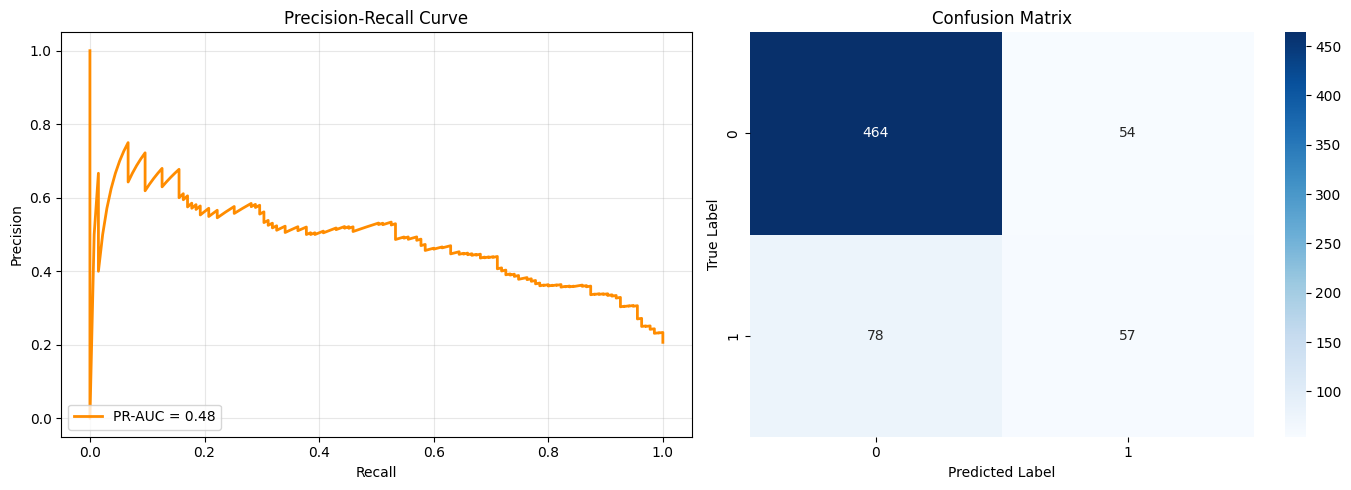

In [1]:
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    precision_recall_curve,
    auc,
    confusion_matrix,
    f1_score
)
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Load your datasets
train_df = pd.read_csv('/content/drive/MyDrive/NLP PROJECT FILES/Binary classification Task/Binarylabel_Train.csv')
val_df = pd.read_csv('/content/drive/MyDrive/NLP PROJECT FILES/Binary classification Task/Binarylabel_Val.csv')

# Initialize TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=15000, ngram_range=(1,3), min_df=3, sublinear_tf=True)

# Correctly separate features (text) and target (label)
X_train_raw, y_train = train_df['text'], train_df['label']
X_val_raw, y_val = val_df['text'], val_df['label']

# Fit the vectorizer on training text and transform both train and val
X_train = vectorizer.fit_transform(X_train_raw)
X_val = vectorizer.transform(X_val_raw)

# 2. Calculate the imbalance ratio
ratio = float(y_train.value_counts()[0] / y_train.value_counts()[1])

# 3. Initialize and train the model
model = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=ratio,
    eval_metric='logloss',
    use_label_encoder=False # Suppress warning for older versions
)

# Removed early stopping parameters as they are not supported by this XGBoost version.
# The model will train for n_estimators rounds without early stopping.
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)]
)

# 4. Generate Predictions and Probabilities for Validation Set
val_probs = model.predict_proba(X_val)[:, 1]
val_preds = model.predict(X_val) # Uses default 0.5 threshold
# 4. Option B: Using a Custom Threshold (e.g., 0.3 or from your validation tuning)
# Lowering the threshold usually increases Recall (finds more minority cases)
custom_threshold = 0.35
val_preds_custom = (val_probs >= custom_threshold).astype(int)


# 5. Calculate Metrics
precision, recall, _ = precision_recall_curve(y_val, val_probs)
pr_auc = auc(recall, precision)
macro_f1 = f1_score(y_val, val_preds, average='macro')

print(f"PR-AUC Score: {pr_auc:.4f}")
print(f"Macro Average F1-Score: {macro_f1:.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_val, val_preds))

# 6. Plotting Results
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot Precision-Recall Curve
ax[0].plot(recall, precision, label=f'PR-AUC = {pr_auc:.2f}', color='darkorange', lw=2)
ax[0].set_xlabel('Recall')
ax[0].set_ylabel('Precision')
ax[0].set_title('Precision-Recall Curve')
ax[0].legend(loc="lower left")
ax[0].grid(alpha=0.3)

# Plot Confusion Matrix
cm = confusion_matrix(y_val, val_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[1])
ax[1].set_xlabel('Predicted Label')
ax[1].set_ylabel('True Label')
ax[1].set_title('Confusion Matrix')

plt.tight_layout()
plt.show()

In [2]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files # Added this line

# 1. Load your test dataset
# Ensure this matches the preprocessing used for the training/validation sets
test_df = pd.read_csv('/content/drive/MyDrive/NLP PROJECT FILES/Binarylabel_Test.csv')

# Correctly prepare X_test by vectorizing the 'text' column
X_test_raw = test_df['text']
X_test = vectorizer.transform(X_test_raw) # Use the 'vectorizer' from previous training cells

# For evaluation, y_test should be the true labels.
# However, based on previous context, the 'label' column in this test CSV might contain NaNs.
# If so, evaluation metrics like classification_report and confusion_matrix cannot be computed.
y_test_true_labels = test_df['label'] # This will be used if true labels are available

# 2. Get Raw Probabilities
# Probabilities are better for imbalanced data as they allow for threshold adjustment
test_probs = model.predict_proba(X_test)[:, 1]

# 3. Option A: Using Default Threshold (0.5)
test_preds_default = model.predict(X_test)

# 4. Option B: Using a Custom Threshold (e.g., 0.3 or from your validation tuning)
# Lowering the threshold usually increases Recall (finds more minority cases)
custom_threshold = 0.35
test_preds_custom = (test_probs >= custom_threshold).astype(int)

# 5. Output Results for the Test Set
print("--- Final Test Set Results (Default 0.5 Threshold) ---")
# These evaluation metrics will only work if y_test_true_labels contains actual, non-NaN labels.
# If you intend to evaluate, ensure your test_df has a 'label' column with ground truth.
# print(classification_report(y_test_true_labels, test_preds_default))

# 6. Save labels to a new column or CSV if needed
test_df['predicted_label'] = test_preds_custom

# Remove the 'text' column before saving
test_df = test_df.drop(columns=['text'])

test_df.to_csv('test_with_predictions.csv', index=False)

# 7. Visualize Test Confusion Matrix
# This will only work if y_test_true_labels contains actual, non-NaN labels.
# if not y_test_true_labels.isnull().all():
#     plt.figure(figsize=(6, 4))
#     cm_test = confusion_matrix(y_test_true_labels, test_preds_custom)
#     sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens')
#     plt.title(f'Test Confusion Matrix (Threshold: {custom_threshold})')
#     plt.xlabel('Predicted')
#     plt.ylabel('Actual')
#     plt.show()
# else:
#     print("Cannot visualize Confusion Matrix: True labels for the test set are missing or all NaN.")

# Display the first few predicted labels
print("\nFirst 10 Predicted Labels (custom threshold):")
print(test_df['predicted_label'].head(10).tolist())

# If you also want to see the default threshold predictions:
# print("\nFirst 10 Predicted Labels (default threshold):")
# test_df['predicted_label_default'] = test_preds_default
# print(test_df['predicted_label_default'].head(10).tolist())

# 6. Save and Download
output_filename = 'Final_Test_Results_with_Labels.csv'
test_df.to_csv(output_filename, index=False)

print(f"Inference Complete. Processed {len(test_df)} rows.")
print(f"Results saved with original data context in: {output_filename}")

# Trigger the download
files.download(output_filename)

--- Final Test Set Results (Default 0.5 Threshold) ---

First 10 Predicted Labels (custom threshold):
[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
Inference Complete. Processed 653 rows.
Results saved with original data context in: Final_Test_Results_with_Labels.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>